# 📊 EDA — Modelo de Propensión de Compra
### Ferreycorp | Prueba Técnica

Este notebook genera las **7 figuras** del análisis exploratorio de datos.

| Figura | Tema |
|--------|------|
| Fig 1  | Estructura del dataset y variable objetivo |
| Fig 2  | Análisis de marcas |
| Fig 3  | Precios y efecto de promociones |
| Fig 4  | Análisis temporal |
| Fig 5  | Perfil demográfico |
| Fig 6  | Mapa de correlaciones |
| Fig 7  | Lealtad de marca y cantidad comprada |


## ⚙️ Celda 1 — Configuración inicial
Instala librerías, sube el archivo CSV y carga los datos.
**Solo ejecuta esta celda una vez.**


In [ ]:
!pip install seaborn --quiet

# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Estilo global de todas las gráficas
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.facecolor'   : '#FAFAFA',
    'figure.facecolor' : 'white',
    'axes.grid'        : True,
    'grid.alpha'       : 0.30,
    'grid.color'       : '#CCCCCC',
})

# Paleta de colores corporativa
C1    = '#2D5FA0'   # azul oscuro
C2    = '#5B9BD5'   # azul medio
C3    = '#A8C8F0'   # azul claro
CRED  = '#D64045'   # rojo acento
CGRAY = '#B0B0B0'   # gris neutro
CB    = [C3, C2, C1, '#1A3F6F', CRED]  # una por cada marca (1 a 5)

print('✅ Librerías listas')


✅ Librerías listas


In [ ]:
# Subir el archivo compras_data.csv
uploaded = files.upload()

# Cargar el dataset
df = pd.read_csv('compras_data.csv')

# Eliminar columna excluida por el diccionario de datos
df = df.drop(columns=['tamanio_ciudad'])

# Columnas auxiliares que usan varias figuras
df['semana']     = ((df['dia_visita'] - 1) // 7) + 1
df['grupo_edad'] = pd.cut(df['edad'],
                          bins=[17, 25, 35, 45, 55, 75],
                          labels=['18-25', '26-35', '36-45', '46-55', '56-75'])
df['ingreso_q']  = pd.qcut(df['ingreso_anual'], q=4,
                           labels=['Q1 (bajo)', 'Q2', 'Q3', 'Q4 (alto)'])

print(f'✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Clientes únicos : {df["id"].nunique()}')
print(f'   Tasa de compra  : {df["incidencia_compra"].mean()*100:.2f}%')
print(f'   Período         : día {df["dia_visita"].min()} → {df["dia_visita"].max()}')


Saving compras_data.csv to compras_data.csv
Saving Diccionario de Datos.txt to Diccionario de Datos.txt
✅ Dataset cargado: 58,693 filas × 26 columnas
   Clientes únicos : 500
   Tasa de compra  : 24.94%
   Período         : día 1 → 730


---
## 📊 Figura 1 — Estructura del dataset

**¿Qué muestra?**
- **Izquierda:** distribución de la variable objetivo `incidencia_compra`.
  El dataset tiene un desbalance 3:1 (75% no compra, 25% sí compra).
  Este desbalance es moderado — se maneja con `class_weight='balanced'` en el modelo.
- **Derecha:** histograma de cuántas visitas tiene cada cliente.
  La mayoría tiene entre 90 y 140 visitas. Hay un outlier con 358 visitas.


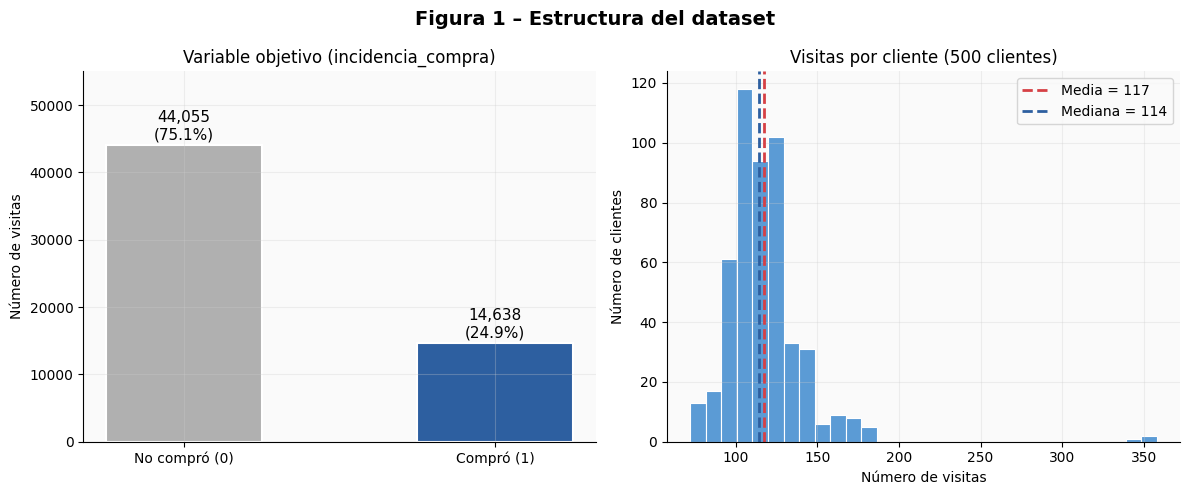

💾 Guardada: fig1_overview.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figura 1 – Estructura del dataset', fontsize=14, fontweight='bold')

# ── Izquierda: distribución de la variable objetivo ──────────────────────
vc = df['incidencia_compra'].value_counts().sort_index()

bars = axes[0].bar(['No compró (0)', 'Compró (1)'], vc.values,
                   color=[CGRAY, C1], edgecolor='white', linewidth=1.5, width=0.5)

# Etiqueta con conteo y porcentaje encima de cada barra
for bar, v in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 400,
                 f'{v:,}\n({v / len(df) * 100:.1f}%)',
                 ha='center', va='bottom', fontsize=11)

axes[0].set_title('Variable objetivo (incidencia_compra)', fontsize=12)
axes[0].set_ylabel('Número de visitas')
axes[0].set_ylim(0, 55_000)

# ── Derecha: visitas por cliente ─────────────────────────────────────────
vpg = df.groupby('id').size()   # cuántas visitas tiene cada cliente

axes[1].hist(vpg, bins=30, color=C2, edgecolor='white', linewidth=0.8)
axes[1].axvline(vpg.mean(),   color=CRED, linestyle='--', linewidth=2,
                label=f'Media = {vpg.mean():.0f}')
axes[1].axvline(vpg.median(), color=C1,   linestyle='--', linewidth=2,
                label=f'Mediana = {vpg.median():.0f}')

axes[1].set_title('Visitas por cliente (500 clientes)', fontsize=12)
axes[1].set_xlabel('Número de visitas')
axes[1].set_ylabel('Número de clientes')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: fig1_overview.png')


---
## 📊 Figura 2 — Análisis de marcas

**¿Qué muestra?**
- **Izquierda:** unidades vendidas por cada marca. La Marca 5 lidera con 4,978 unidades
  pese a ser la más cara ($2.65 promedio).
- **Derecha:** tasa de compra según la última marca que compró el cliente.
  Los clientes que compraron Marca 5 la última vez tienen **56.5% de probabilidad**
  de comprar en su siguiente visita — más del doble de la media global (24.9%).
  Esto hace de `ultima_marca_comprada` el predictor más fuerte del modelo.


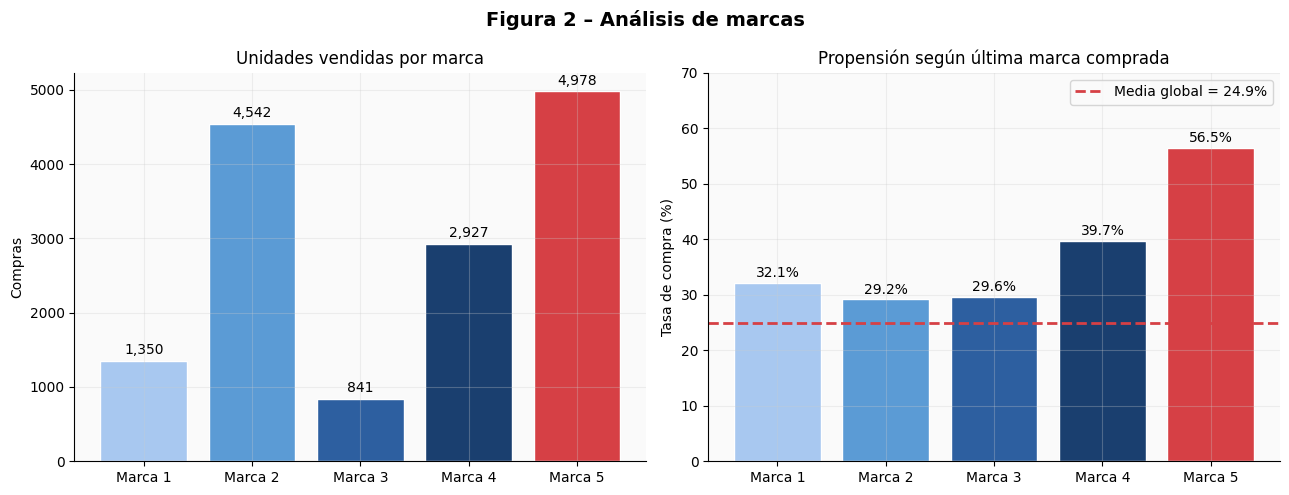

💾 Guardada: fig2_marcas.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figura 2 – Análisis de marcas', fontsize=14, fontweight='bold')

# Solo filas donde hubo compra
bought = df[df['incidencia_compra'] == 1]

# ── Izquierda: unidades vendidas por marca ────────────────────────────────
brand_sales = bought['id_marca'].value_counts().sort_index()
brand_sales = brand_sales[brand_sales.index > 0]   # excluir id_marca=0 (sin compra)

bars = axes[0].bar([f'Marca {i}' for i in brand_sales.index],
                   brand_sales.values, color=CB, edgecolor='white')
for bar, v in zip(bars, brand_sales.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 50, f'{v:,}',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_title('Unidades vendidas por marca', fontsize=12)
axes[0].set_ylabel('Compras')

# ── Derecha: propensión según última marca comprada ───────────────────────
marca_prop = {}
for m in range(1, 6):
    sub = df[df['ultima_marca_comprada'] == m]
    if len(sub) > 0:
        marca_prop[f'Marca {m}'] = sub['incidencia_compra'].mean() * 100

media_global = df['incidencia_compra'].mean() * 100

bars2 = axes[1].bar(list(marca_prop.keys()), list(marca_prop.values()),
                    color=CB, edgecolor='white')
axes[1].axhline(media_global, color=CRED, linestyle='--', linewidth=2,
                label=f'Media global = {media_global:.1f}%')
for bar, v in zip(bars2, marca_prop.values()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Propensión según última marca comprada', fontsize=12)
axes[1].set_ylabel('Tasa de compra (%)')
axes[1].set_ylim(0, 70)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig2_marcas.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: fig2_marcas.png')


---
## 📊 Figura 3 — Precios y efecto de promociones

**¿Qué muestra?**
- **Izquierda:** boxplots de precio por marca. Confirma 5 segmentos de precio
  bien diferenciados (Marca 1 ~$1.39 económica → Marca 5 ~$2.65 premium).
  La poca variabilidad (caja angosta) indica precios estables en el tiempo.
- **Derecha:** efecto de las promociones sobre la tasa de compra.
  La **Marca 5** tiene el mayor uplift promocional (+6.9 pp).
  La **Marca 3** es casi insensible a promociones (+0.7 pp).


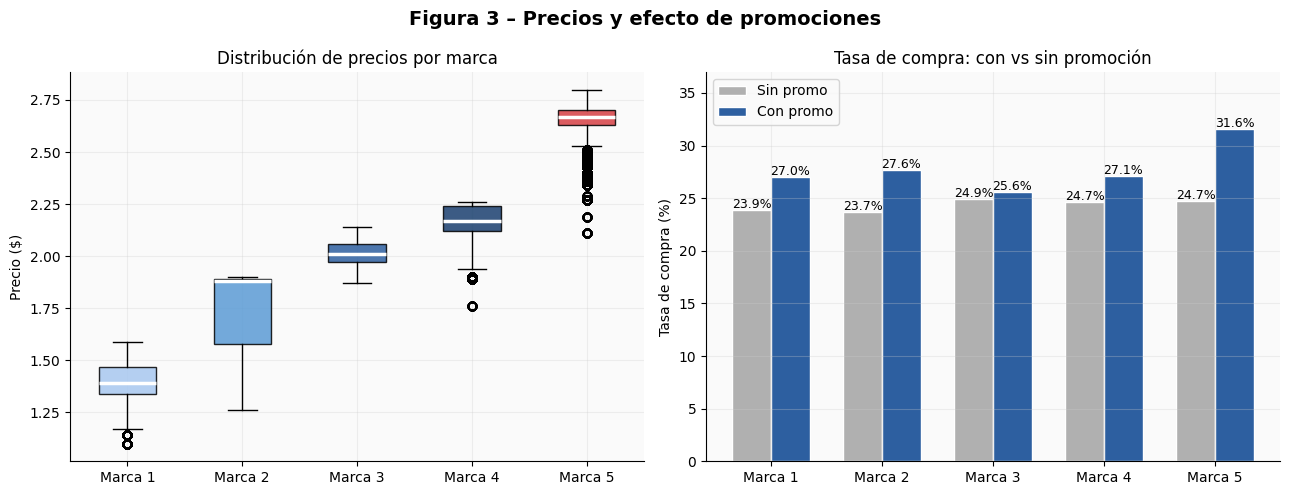

💾 Guardada: fig3_precios_promos.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figura 3 – Precios y efecto de promociones', fontsize=14, fontweight='bold')

# ── Izquierda: boxplots de precio por marca ───────────────────────────────
price_data = [df[f'precio_marca_{m}'] for m in range(1, 6)]

bp = axes[0].boxplot(price_data, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], CB):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

axes[0].set_xticklabels([f'Marca {i}' for i in range(1, 6)])
axes[0].set_title('Distribución de precios por marca', fontsize=12)
axes[0].set_ylabel('Precio ($)')

# ── Derecha: uplift de promociones ───────────────────────────────────────
con_promo   = []
sin_promo   = []
for m in range(1, 6):
    col = f'promo_marca_{m}'
    con_promo.append(df[df[col] == 1]['incidencia_compra'].mean() * 100)
    sin_promo.append(df[df[col] == 0]['incidencia_compra'].mean() * 100)

x = np.arange(5)
w = 0.35
b1 = axes[1].bar(x - w/2, sin_promo, w, label='Sin promo', color=CGRAY, edgecolor='white')
b2 = axes[1].bar(x + w/2, con_promo, w, label='Con promo', color=C1,   edgecolor='white')

for bar, v in zip(b1, sin_promo):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.2,
                 f'{v:.1f}%', ha='center', fontsize=9)
for bar, v in zip(b2, con_promo):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.2,
                 f'{v:.1f}%', ha='center', fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Marca {i}' for i in range(1, 6)])
axes[1].set_title('Tasa de compra: con vs sin promoción', fontsize=12)
axes[1].set_ylabel('Tasa de compra (%)')
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 37)

plt.tight_layout()
plt.savefig('fig3_precios_promos.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: fig3_precios_promos.png')


---
## 📊 Figura 4 — Análisis temporal

**¿Qué muestra?**
- **Izquierda:** evolución de la tasa de compra diaria suavizada con media móvil de 14 días.
  Se observa una tendencia creciente: de 23.3% en Q1 a 26.4% en Q3.
  Las líneas punteadas marcan el inicio de cada trimestre.
- **Derecha:** volumen de visitas semanales (barras) y tasa de compra (línea).
  El volumen es estable (~80-100 visitas/semana), descartando sesgos por estacionalidad.


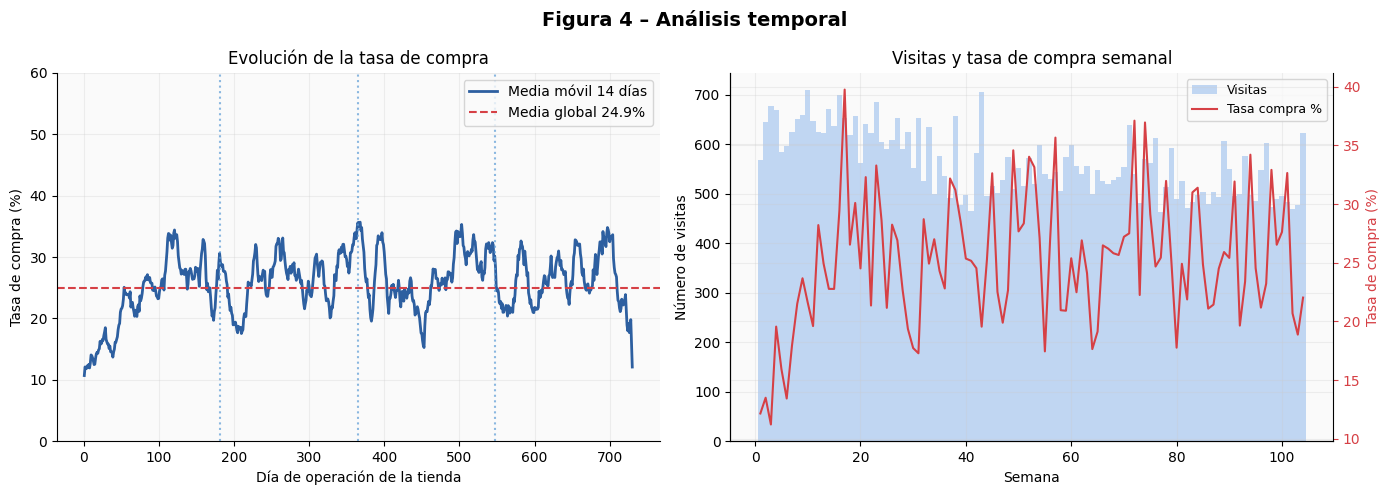

💾 Guardada: fig4_temporal.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figura 4 – Análisis temporal', fontsize=14, fontweight='bold')

# ── Izquierda: tasa de compra diaria (media móvil) ───────────────────────
df_daily = (df.sort_values('dia_visita')
              .groupby('dia_visita')
              .agg(visitas=('incidencia_compra', 'count'),
                   compras=('incidencia_compra', 'sum'))
              .reset_index())
df_daily['tasa']      = df_daily['compras'] / df_daily['visitas']
df_daily['tasa_roll'] = df_daily['tasa'].rolling(14, center=True, min_periods=5).mean()

axes[0].plot(df_daily['dia_visita'], df_daily['tasa_roll'] * 100,
             color=C1, linewidth=2, label='Media móvil 14 días')
axes[0].axhline(df['incidencia_compra'].mean() * 100,
                color=CRED, linestyle='--', linewidth=1.5,
                label=f'Media global {df["incidencia_compra"].mean()*100:.1f}%')
for q in [182, 365, 548]:   # inicio de cada trimestre
    axes[0].axvline(q, color=C2, linestyle=':', alpha=0.7)

axes[0].set_xlabel('Día de operación de la tienda')
axes[0].set_ylabel('Tasa de compra (%)')
axes[0].set_title('Evolución de la tasa de compra', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 60)

# ── Derecha: visitas semanales con eje doble ──────────────────────────────
weekly = (df.groupby('semana')
            .agg(visitas=('incidencia_compra', 'count'),
                 compras=('incidencia_compra', 'sum'))
            .reset_index())
weekly['tasa'] = weekly['compras'] / weekly['visitas']

weekly = weekly[weekly['semana'] < df['semana'].max()]

axes[1].bar(weekly['semana'], weekly['visitas'],
            color=C3, alpha=0.7, label='Visitas', width=1)

ax_der = axes[1].twinx()   # segundo eje Y a la derecha
ax_der.plot(weekly['semana'], weekly['tasa'] * 100,
            color=CRED, linewidth=1.5, label='Tasa compra %')
ax_der.set_ylabel('Tasa de compra (%)', color=CRED)
ax_der.tick_params(axis='y', colors=CRED)
ax_der.spines['right'].set_visible(True)
ax_der.spines['top'].set_visible(False)

axes[1].set_xlabel('Semana')
axes[1].set_ylabel('Número de visitas')
axes[1].set_title('Visitas y tasa de compra semanal', fontsize=12)
l1, lb1 = axes[1].get_legend_handles_labels()
l2, lb2 = ax_der.get_legend_handles_labels()
axes[1].legend(l1 + l2, lb1 + lb2, fontsize=9)

plt.tight_layout()
plt.savefig('fig4_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: fig4_temporal.png')


---
## 📊 Figura 5 — Perfil demográfico

**¿Qué muestra?** (4 paneles)
- **Edad:** a mayor edad, mayor propensión. Los mayores de 56 años compran al 30.6%.
- **Ingreso:** el cuartil más rico (Q4) compra al 30%, el más pobre (Q1) al 20.2%.
- **Educación:** nivel medio (2) tiene la mayor tasa (29.7%). Nivel superior (3) la menor (18.1%).
- **Género × Estado civil:** las mujeres solteras lideran con 27.7%.
  La línea roja en todos los paneles es la media global de referencia (24.9%).


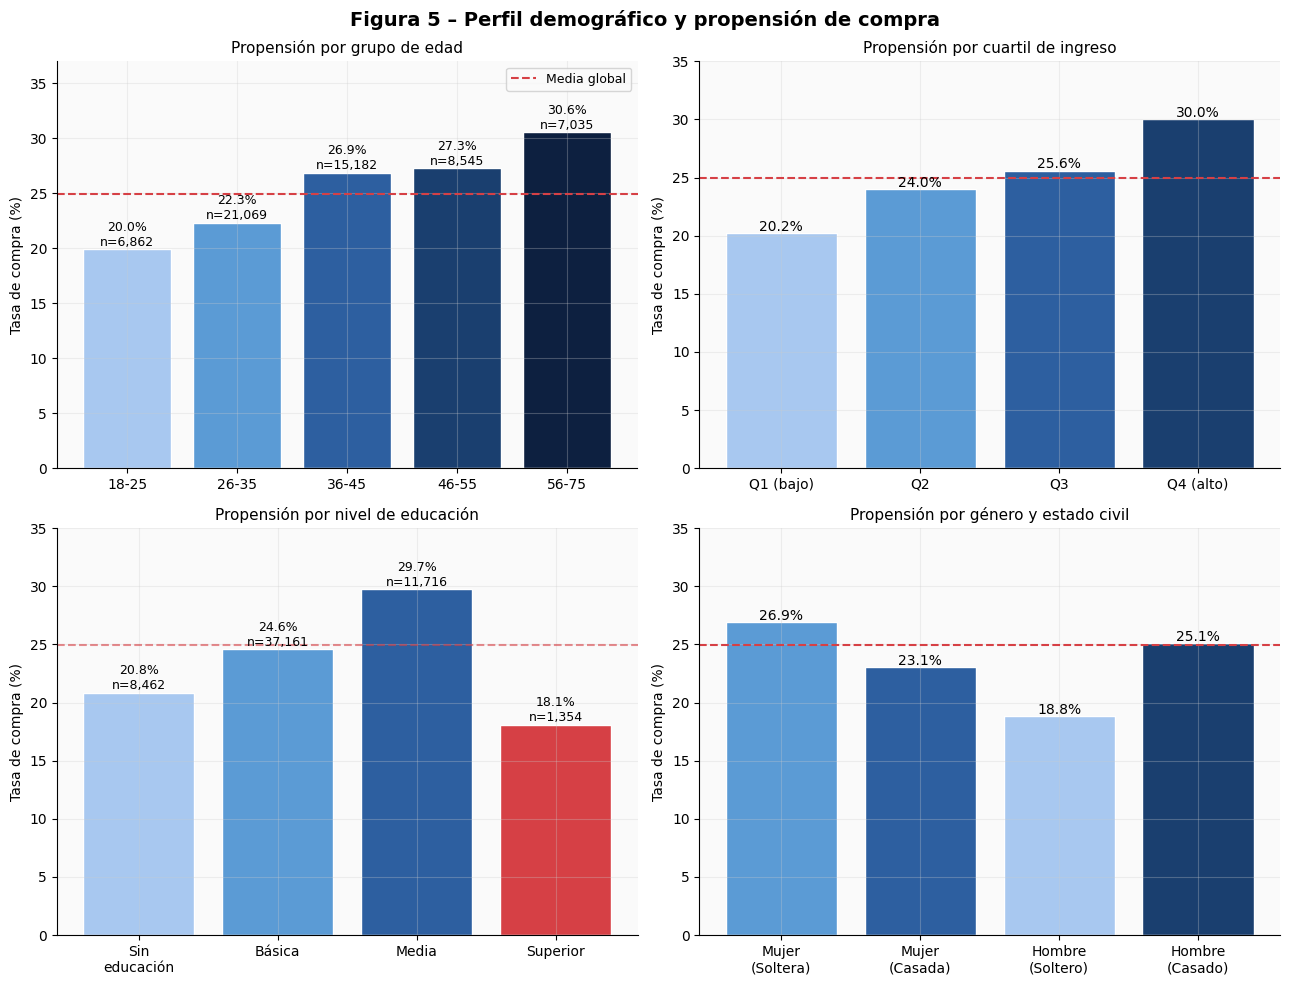

💾 Guardada: fig5_demograficos.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Figura 5 – Perfil demográfico y propensión de compra',
             fontsize=14, fontweight='bold')

media_global = df['incidencia_compra'].mean() * 100

# ── Panel (0,0): edad ────────────────────────────────────────────────────
age_prop  = df.groupby('grupo_edad', observed=True)['incidencia_compra'].mean() * 100
age_count = df.groupby('grupo_edad', observed=True).size()

bars = axes[0, 0].bar(age_prop.index, age_prop.values,
                      color=[C3, C2, C1, '#1A3F6F', '#0D2040'], edgecolor='white')
axes[0, 0].axhline(media_global, color=CRED, linestyle='--', linewidth=1.5,
                   label='Media global')
for bar, v, n in zip(bars, age_prop.values, age_count.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                   f'{v:.1f}%\nn={n:,}', ha='center', fontsize=9)
axes[0, 0].set_title('Propensión por grupo de edad', fontsize=11)
axes[0, 0].set_ylabel('Tasa de compra (%)')
axes[0, 0].set_ylim(0, 37)
axes[0, 0].legend(fontsize=9)

# ── Panel (0,1): ingreso ─────────────────────────────────────────────────
inc_prop = df.groupby('ingreso_q', observed=True)['incidencia_compra'].mean() * 100

bars = axes[0, 1].bar(inc_prop.index, inc_prop.values,
                      color=[C3, C2, C1, '#1A3F6F'], edgecolor='white')
axes[0, 1].axhline(media_global, color=CRED, linestyle='--', linewidth=1.5)
for bar, v in zip(bars, inc_prop.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, v + 0.2,
                   f'{v:.1f}%', ha='center', fontsize=10)
axes[0, 1].set_title('Propensión por cuartil de ingreso', fontsize=11)
axes[0, 1].set_ylabel('Tasa de compra (%)')
axes[0, 1].set_ylim(0, 35)

# ── Panel (1,0): educación ───────────────────────────────────────────────
edu_labels = {0: 'Sin\neducación', 1: 'Básica', 2: 'Media', 3: 'Superior'}
edu_prop   = df.groupby('nivel_educacion', observed=True)['incidencia_compra'].mean() * 100
edu_count  = df.groupby('nivel_educacion', observed=True).size()

bars = axes[1, 0].bar([edu_labels[i] for i in edu_prop.index], edu_prop.values,
                      color=[C3, C2, C1, CRED], edgecolor='white')
axes[1, 0].axhline(media_global, color=CRED, linestyle='--', linewidth=1.5, alpha=0.6)
for bar, v, n in zip(bars, edu_prop.values, edu_count.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, v + 0.3,
                   f'{v:.1f}%\nn={n:,}', ha='center', fontsize=9)
axes[1, 0].set_title('Propensión por nivel de educación', fontsize=11)
axes[1, 0].set_ylabel('Tasa de compra (%)')
axes[1, 0].set_ylim(0, 35)

# ── Panel (1,1): género × estado civil ───────────────────────────────────
combos = [('Mujer\n(Soltera)', 0, 0), ('Mujer\n(Casada)', 0, 1),
          ('Hombre\n(Soltero)', 1, 0), ('Hombre\n(Casado)', 1, 1)]
labels_gc = [c[0] for c in combos]
vals_gc   = [df[(df['genero'] == g) & (df['estado_civil'] == e)]
               ['incidencia_compra'].mean() * 100
             for _, g, e in combos]

bars = axes[1, 1].bar(labels_gc, vals_gc,
                      color=[C2, C1, C3, '#1A3F6F'], edgecolor='white')
axes[1, 1].axhline(media_global, color=CRED, linestyle='--', linewidth=1.5)
for bar, v in zip(bars, vals_gc):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.2,
                   f'{v:.1f}%', ha='center', fontsize=10)
axes[1, 1].set_title('Propensión por género y estado civil', fontsize=11)
axes[1, 1].set_ylabel('Tasa de compra (%)')
axes[1, 1].set_ylim(0, 35)

plt.tight_layout()
plt.savefig('fig5_demograficos.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: fig5_demograficos.png')


---
## 📊 Figura 6 — Mapa de correlaciones

**¿Qué muestra?**
Correlaciones de Pearson entre variables. Solo el triángulo inferior para evitar redundancia.

- 🔵 Azul = correlación positiva | 🔴 Rojo = correlación negativa
- `edad` e `ingreso_anual` tienen correlación positiva con `compra` (~0.12 y ~0.09).
- `precio_marca_1` y `precio_marca_2` tienen correlación negativa débil con la compra.
- **Importante:** correlaciones bajas no significan variables irrelevantes.
  Los modelos de árbol (como el que usamos) capturan relaciones no lineales
  que Pearson no detecta.


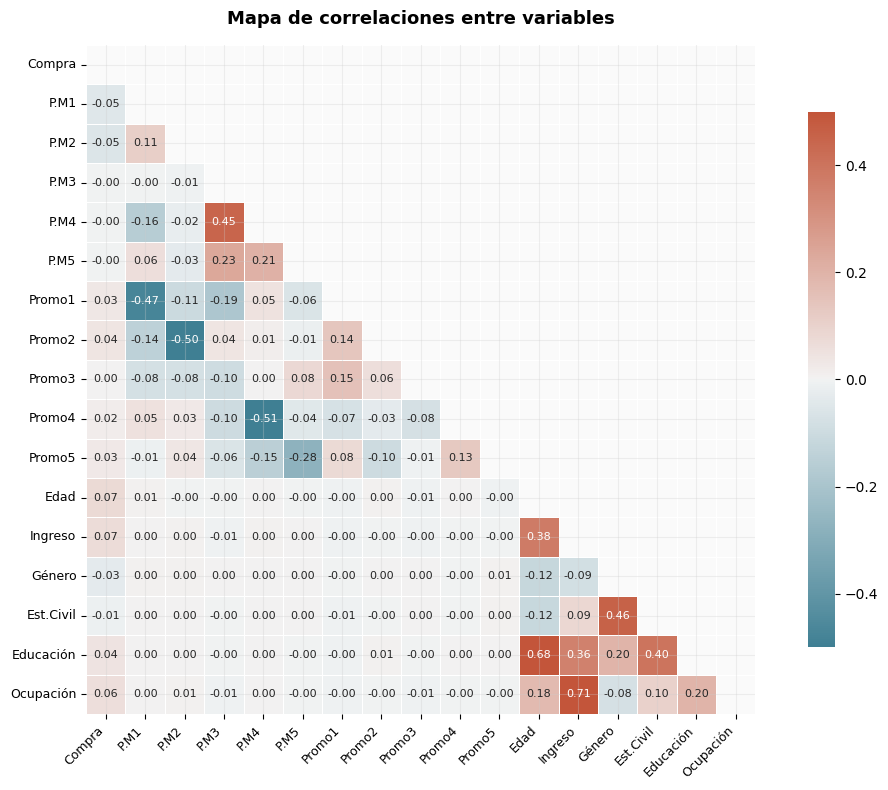

💾 Guardada: fig6_correlacion.png


In [ ]:
# Columnas para la matriz de correlación
cols_corr = [
    'incidencia_compra',
    'precio_marca_1', 'precio_marca_2', 'precio_marca_3', 'precio_marca_4', 'precio_marca_5',
    'promo_marca_1',  'promo_marca_2',  'promo_marca_3',  'promo_marca_4',  'promo_marca_5',
    'edad', 'ingreso_anual', 'genero', 'estado_civil', 'nivel_educacion', 'ocupacion',
]

# Nombres cortos para que quepan en el heatmap
rename = {
    'incidencia_compra': 'Compra',
    'precio_marca_1': 'P.M1', 'precio_marca_2': 'P.M2', 'precio_marca_3': 'P.M3',
    'precio_marca_4': 'P.M4', 'precio_marca_5': 'P.M5',
    'promo_marca_1': 'Promo1', 'promo_marca_2': 'Promo2', 'promo_marca_3': 'Promo3',
    'promo_marca_4': 'Promo4', 'promo_marca_5': 'Promo5',
    'edad': 'Edad', 'ingreso_anual': 'Ingreso', 'genero': 'Género',
    'estado_civil': 'Est.Civil', 'nivel_educacion': 'Educación', 'ocupacion': 'Ocupación',
}

corr = df[cols_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # oculta triángulo superior

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    corr,
    mask=mask,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0, vmin=-0.5, vmax=0.5,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, ax=ax, square=True,
    cbar_kws={'shrink': 0.8},
)
short = [rename.get(c, c) for c in cols_corr]
ax.set_xticklabels(short, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short, rotation=0, fontsize=9)
ax.set_title('Mapa de correlaciones entre variables',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('fig6_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: fig6_correlacion.png')


---
## 📊 Figura 7 — Lealtad de marca y cantidad comprada

**¿Qué muestra?**
- **Izquierda:** tasa de repetición de marca. El **79.9% de los compradores** vuelven
  a comprar la misma marca que compraron la última vez. Es el índice de lealtad más alto
  del dataset y explica por qué `ultima_marca_comprada` es tan predictivo.
- **Derecha:** distribución de cuántas unidades compran los clientes en cada visita.
  La mayoría compra entre 1 y 3 unidades. El modo es 3.


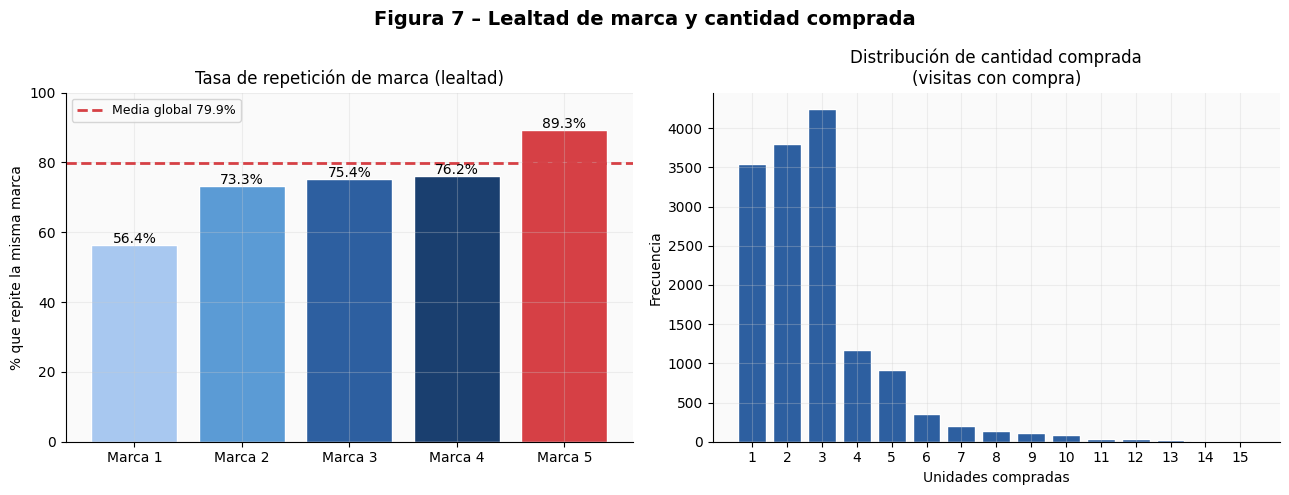

💾 Guardada: fig7_lealtad_cantidad.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figura 7 – Lealtad de marca y cantidad comprada',
             fontsize=14, fontweight='bold')

# Solo compras donde había una compra previa registrada
bought      = df[df['incidencia_compra'] == 1].copy()
bought_prev = bought[bought['ultima_marca_comprada'] > 0].copy()

# ── Izquierda: lealtad por marca ─────────────────────────────────────────
loyalty = {}
for m in range(1, 6):
    sub = bought_prev[bought_prev['id_marca'] == m]
    if len(sub) > 0:
        # ¿cuántos compraron HOY la misma marca que compraron la ÚLTIMA vez?
        loyalty[f'Marca {m}'] = (sub['id_marca'] == sub['ultima_marca_comprada']).mean() * 100

lealtad_global = (bought_prev['id_marca'] == bought_prev['ultima_marca_comprada']).mean() * 100

bars = axes[0].bar(list(loyalty.keys()), list(loyalty.values()),
                   color=CB, edgecolor='white')
axes[0].axhline(lealtad_global, color=CRED, linestyle='--', linewidth=2,
                label=f'Media global {lealtad_global:.1f}%')
for bar, v in zip(bars, loyalty.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'{v:.1f}%', ha='center', fontsize=10)
axes[0].set_title('Tasa de repetición de marca (lealtad)', fontsize=12)
axes[0].set_ylabel('% que repite la misma marca')
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=9)

# ── Derecha: distribución de cantidad comprada ────────────────────────────
qty_counts = df[df['incidencia_compra'] == 1]['cantidad'].value_counts().sort_index()

axes[1].bar(qty_counts.index, qty_counts.values, color=C1, edgecolor='white')
axes[1].set_title('Distribución de cantidad comprada\n(visitas con compra)', fontsize=12)
axes[1].set_xlabel('Unidades compradas')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xticks(range(1, 16))

plt.tight_layout()
plt.savefig('fig7_lealtad_cantidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Guardada: fig7_lealtad_cantidad.png')


---
## 💾 Descargar todas las figuras


In [ ]:
from google.colab import files
import glob

pngs = sorted(glob.glob('fig*.png'))
print(f'Figuras guardadas en /content/: {pngs}')
print()
print('Descargando...')
for f in pngs:
    files.download(f)
    print(f'  ✅ {f}')


Figuras guardadas en /content/: ['fig1_overview.png', 'fig2_marcas.png', 'fig3_precios_promos.png', 'fig4_temporal.png', 'fig5_demograficos.png', 'fig6_correlacion.png', 'fig7_lealtad_cantidad.png']

Descargando...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ fig1_overview.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ fig6_correlacion.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ fig7_lealtad_cantidad.png
